In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import TypedDict, Literal,Annotated
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
import operator

from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langgraph.checkpoint.memory import InMemorySaver

In [12]:
llm = ChatGroq(model="openai/gpt-oss-120b")

In [4]:
class JokeState(TypedDict):
    topic:str
    joke:str
    explanation:str
    

In [5]:
def generate_joke(state: JokeState):
    
    prompt= f'generate a joke pn the topic {state['topic']}'
    response = llm.invoke(prompt).content
    
    return {'joke': response}

In [6]:
def generate_explanation(state: JokeState):
    
    prompt = f"write an explanation for the joke - {state["joke"]}"
    response = llm.invoke(prompt).content
    
    return {'explanation': response}

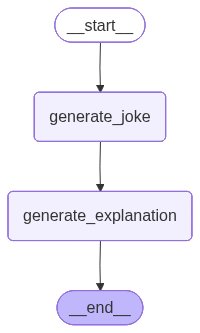

In [8]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)


graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)


checkpointer = InMemorySaver()


workflow = graph.compile(checkpointer=checkpointer)
workflow

In [13]:
config1 = {'configurable': {"thread_id": "1"}}

initial_state = {
    "topic": "Indian AI Development"

}
workflow.invoke(initial_state, config=config1)

{'topic': 'Indian AI Development',
 'joke': 'Sure, here’s a light‑hearted one:\n\n**Why did the Indian AI start doing yoga?**  \nBecause it heard that to achieve *deep learning* you first need to master *deep breathing*—and it wanted to stay flexible while it “trained” its neural networks! 😄',
 'explanation': '### Why the joke works  \n\n| Element of the joke | What it literally means | The pun / double‑meaning | Why it’s funny |\n|---------------------|------------------------|--------------------------|----------------|\n| **“Indian AI”** | An artificial‑intelligence system that is “Indian” (either built in India or given an Indian persona). | Sets up a cultural cue: yoga is strongly associated with India in the popular imagination. | Gives the listener a mental picture of a robot/algorithm wearing a yoga mat, which is already a little absurd. |\n| **“start doing yoga”** | The AI begins to practice the physical discipline of yoga. | “Doing yoga” is a literal activity, but the joke wi

In [15]:
config1 = {'configurable': {"thread_id": "1"}}

initial_state = {
    "topic": "Pizza"

}
workflow.invoke(initial_state, config=config1)

{'topic': 'Pizza',
 'joke': 'Why did the pizza apply for a job?  \n\nBecause it heard the position was *a slice* above the rest and it wanted to *topping* the competition! 🍕😄',
 'explanation': '### Why the pizza’s job‑application joke works  \n\n| Part of the joke | What it says | The wordplay / pun | Why it’s funny |\n|------------------|--------------|--------------------|----------------|\n| **“Why did the pizza apply for a job?”** | Sets up a classic “why‑did‑the‑chicken‑cross‑the‑road” style question. | It gives a piece of food (a pizza) a human activity—applying for a job. This anthropomorphism is already a little absurd, which primes the listener for a goofy punch‑line. | The absurdity makes us expect a silly answer, so we’re ready to laugh. |\n| **“Because it heard the position was *a slice* above the rest…”** | The “position” (the job) is described as “a slice above the rest.” | *Slice* is a term that belongs to pizza (a pizza is cut into slices). The phrase “a step above the 

In [14]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'Indian AI Development', 'joke': 'Sure, here’s a light‑hearted one:\n\n**Why did the Indian AI start doing yoga?**  \nBecause it heard that to achieve *deep learning* you first need to master *deep breathing*—and it wanted to stay flexible while it “trained” its neural networks! 😄', 'explanation': '### Why the joke works  \n\n| Element of the joke | What it literally means | The pun / double‑meaning | Why it’s funny |\n|---------------------|------------------------|--------------------------|----------------|\n| **“Indian AI”** | An artificial‑intelligence system that is “Indian” (either built in India or given an Indian persona). | Sets up a cultural cue: yoga is strongly associated with India in the popular imagination. | Gives the listener a mental picture of a robot/algorithm wearing a yoga mat, which is already a little absurd. |\n| **“start doing yoga”** | The AI begins to practice the physical discipline of yoga. | “Doing yoga” is a literal activi

In [16]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why did the pizza apply for a job?  \n\nBecause it heard the position was *a slice* above the rest and it wanted to *topping* the competition! 🍕😄', 'explanation': '### Why the pizza’s job‑application joke works  \n\n| Part of the joke | What it says | The wordplay / pun | Why it’s funny |\n|------------------|--------------|--------------------|----------------|\n| **“Why did the pizza apply for a job?”** | Sets up a classic “why‑did‑the‑chicken‑cross‑the‑road” style question. | It gives a piece of food (a pizza) a human activity—applying for a job. This anthropomorphism is already a little absurd, which primes the listener for a goofy punch‑line. | The absurdity makes us expect a silly answer, so we’re ready to laugh. |\n| **“Because it heard the position was *a slice* above the rest…”** | The “position” (the job) is described as “a slice above the rest.” | *Slice* is a term that belongs to pizza (a pizza is cut into slices). The phras

In [17]:
config2 = {'configurable': {"thread_id": "2"}}

initial_state = {
    "topic": "Pizza"

}
workflow.invoke(initial_state, config=config2)

{'topic': 'Pizza',
 'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for someone with a lot of *dough* and great *slice*‑management skills! 🍕😄',
 'explanation': '**Explanation of the joke**\n\n> **Why did the pizza apply for a job?**  \n> **Because it heard the company was looking for someone with a lot of *dough* and great *slice*‑management skills!** 🍕😄  \n\n---\n\n### 1. The two key puns\n\n| Word in the punch‑line | Literal meaning (pizza‑related) | Figurative meaning (job‑related) |\n|------------------------|---------------------------------|-----------------------------------|\n| **Dough**              | The raw, kneaded mixture that becomes pizza crust. | Slang for money (“a lot of dough”) – a quality many employers value because it implies financial stability or the ability to bring revenue. |\n| **Slice** (or *slice‑management*) | A piece of pizza that you eat. | “Slice” can be taken as a metaphor for a *portion* of something (e.g., a ma

In [18]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for someone with a lot of *dough* and great *slice*‑management skills! 🍕😄', 'explanation': '**Explanation of the joke**\n\n> **Why did the pizza apply for a job?**  \n> **Because it heard the company was looking for someone with a lot of *dough* and great *slice*‑management skills!** 🍕😄  \n\n---\n\n### 1. The two key puns\n\n| Word in the punch‑line | Literal meaning (pizza‑related) | Figurative meaning (job‑related) |\n|------------------------|---------------------------------|-----------------------------------|\n| **Dough**              | The raw, kneaded mixture that becomes pizza crust. | Slang for money (“a lot of dough”) – a quality many employers value because it implies financial stability or the ability to bring revenue. |\n| **Slice** (or *slice‑management*) | A piece of pizza that you eat. | “Slice” can be taken as a metaphor for a *portion* of s

# Time Travel

In [22]:
workflow.get_state({'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f16f05e-b61c-6fc2-8000-8f28b488b036'}})

StateSnapshot(values={'topic': 'Pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f16f05e-b61c-6fc2-8000-8f28b488b036'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-23T13:17:43.977147+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f16f05e-b619-67d4-bfff-f06b9e6dcca9'}}, tasks=(PregelTask(id='1a11cbe4-0237-1d84-2750-048497122487', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for someone with a lot of *dough* and great *slice*‑management skills! 🍕😄'}),), interrupts=())

In [23]:
workflow.invoke(None, {'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f16f05e-b61c-6fc2-8000-8f28b488b036'}})

{'topic': 'Pizza',
 'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for someone with *dough*‑cious experience and a *slice* of talent! 🍕😄',
 'explanation': '**Explanation of the joke**\n\n1. **Set‑up:**  \n   *“Why did the pizza apply for a job?”*  \n   This line creates a silly mental image—food (a pizza) behaving like a person and looking for employment. The absurdity primes the listener for a punny punchline.\n\n2. **Punchline:**  \n   *“Because it heard the company was looking for someone with *dough‑cious* experience and a *slice* of talent!”*  \n\n   The humor comes from two wordplays that replace ordinary business‑jargon terms with pizza‑related vocabulary:\n\n   - **“Dough‑cious experience”** – The word *dough* is the raw ingredient used to make pizza crust. By attaching the suffix “‑cious” (as in “delicious”), the phrase mimics “extensive experience” or “impressive experience.” The joke suggests the pizza thinks the job requires “dough‑c

# Update State

In [28]:
workflow.update_state({'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f16f05e-b61c-6fc2-8000-8f28b488b036'}}, {'topic': 'Samosa'})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f16f25f-e912-6cb5-8001-709458ccc61e'}}

In [29]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f16f25f-e912-6cb5-8001-709458ccc61e'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-06-23T17:07:20.059589+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f16f05e-b61c-6fc2-8000-8f28b488b036'}}, tasks=(PregelTask(id='5d2d3ed4-a267-767f-8b34-7679dae29839', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'Samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f16f25b-e0fb-647e-8001-d27352d454dd'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-06-23T17:05:31.836849+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id

### checkpoint Id change ho k new id aa jayegi

In [30]:
workflow.invoke(None, {'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f16f25f-e912-6cb5-8001-709458ccc61e'}})

{'topic': 'Samosa',
 'joke': 'Why did the samosa go to therapy?  \n\nBecause it was feeling *crumby* on the inside, but still wanted to *roll* with the punches!',
 'explanation': '**Explanation of the joke**\n\n1. **Anthropomorphism** – The joke treats a samosa, a fried pastry, as if it were a person who can have feelings and go to therapy. Giving a food item human emotions is a classic comedic device that creates a silly, unexpected image.\n\n2. **Pun on “crumby / crummy”** –  \n   - *Crumby* (spelled with an “e”) literally describes something that is full of crumbs, which is exactly what a samosa can be after it’s been fried or eaten.  \n   - *Crummy* (spelled with an “i”) is a colloquial way of saying “feeling bad, miserable, or low‑self‑esteem.”  \n   The joke swaps the two spellings, so the samosa is “feeling crumby on the inside,” meaning it’s both physically crumb‑laden and emotionally down.\n\n3. **Pun on “roll with the punches”** –  \n   - The idiom *roll with the punches* mea

In [ ]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Samosa', 'joke': 'Why did the samosa go to therapy?  \n\nBecause it was feeling *crumby* on the inside, but still wanted to *roll* with the punches!', 'explanation': '**Explanation of the joke**\n\n1. **Anthropomorphism** – The joke treats a samosa, a fried pastry, as if it were a person who can have feelings and go to therapy. Giving a food item human emotions is a classic comedic device that creates a silly, unexpected image.\n\n2. **Pun on “crumby / crummy”** –  \n   - *Crumby* (spelled with an “e”) literally describes something that is full of crumbs, which is exactly what a samosa can be after it’s been fried or eaten.  \n   - *Crummy* (spelled with an “i”) is a colloquial way of saying “feeling bad, miserable, or low‑self‑esteem.”  \n   The joke swaps the two spellings, so the samosa is “feeling crumby on the inside,” meaning it’s both physically crumb‑laden and emotionally down.\n\n3. **Pun on “roll with the punches”** –  \n   - The idiom *roll w

: 